In [2]:
options(repr.plot.width=8, repr.plot.height=8,repr.plot.res=300)

In [1]:
brms_regses_final_production <- readRDS("~/OneDrive/Spring 2026/HLM/Data & Workspaces/brms_regses_final_production.rds")
summary(brms_regses_final_production)

library(performance)
icc_results<-icc(brms_regses_final_production)
print(icc_results)

 Family: bernoulli 
  Links: mu = logit 
Formula: is_sped ~ regses + (1 | Schl) 
   Data: df_regses_final (Number of observations: 139601) 
  Draws: 4 chains, each with iter = 5000; warmup = 2500; thin = 1;
         total post-warmup draws = 10000

Multilevel Hyperparameters:
~Schl (Number of levels: 222) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     0.71      0.04     0.64     0.80 1.00     1145     1764

Regression Coefficients:
                               Estimate Est.Error l-95% CI u-95% CI Rhat
Intercept                         -2.04      0.05    -2.14    -1.94 1.01
regsesAfricanAmerican_Female_0     0.18      0.04     0.11     0.25 1.00
regsesAfricanAmerican_Female_1     0.52      0.04     0.45     0.59 1.00
regsesAfricanAmerican_Male_0       0.82      0.03     0.76     0.89 1.00
regsesAfricanAmerican_Male_1       1.12      0.03     1.06     1.19 1.00
regsesAmericanIndian_Female_0      0.06      0.23    -0.41     0.48 1.00
regsesA

Warning message:
"package 'performance' was built under R version 4.4.3"


# Intraclass Correlation Coefficient

    Adjusted ICC: 0.134
  Unadjusted ICC: 0.127


## Diagnostics

Warning message:
"package 'bayesplot' was built under R version 4.4.3"
This is bayesplot version 1.11.1

- Online documentation and vignettes at mc-stan.org/bayesplot

- bayesplot theme set to bayesplot::theme_default()

   * Does _not_ affect other ggplot2 plots

   * See ?bayesplot_theme_set for details on theme setting

Warning message:
"package 'ggplot2' was built under R version 4.4.3"


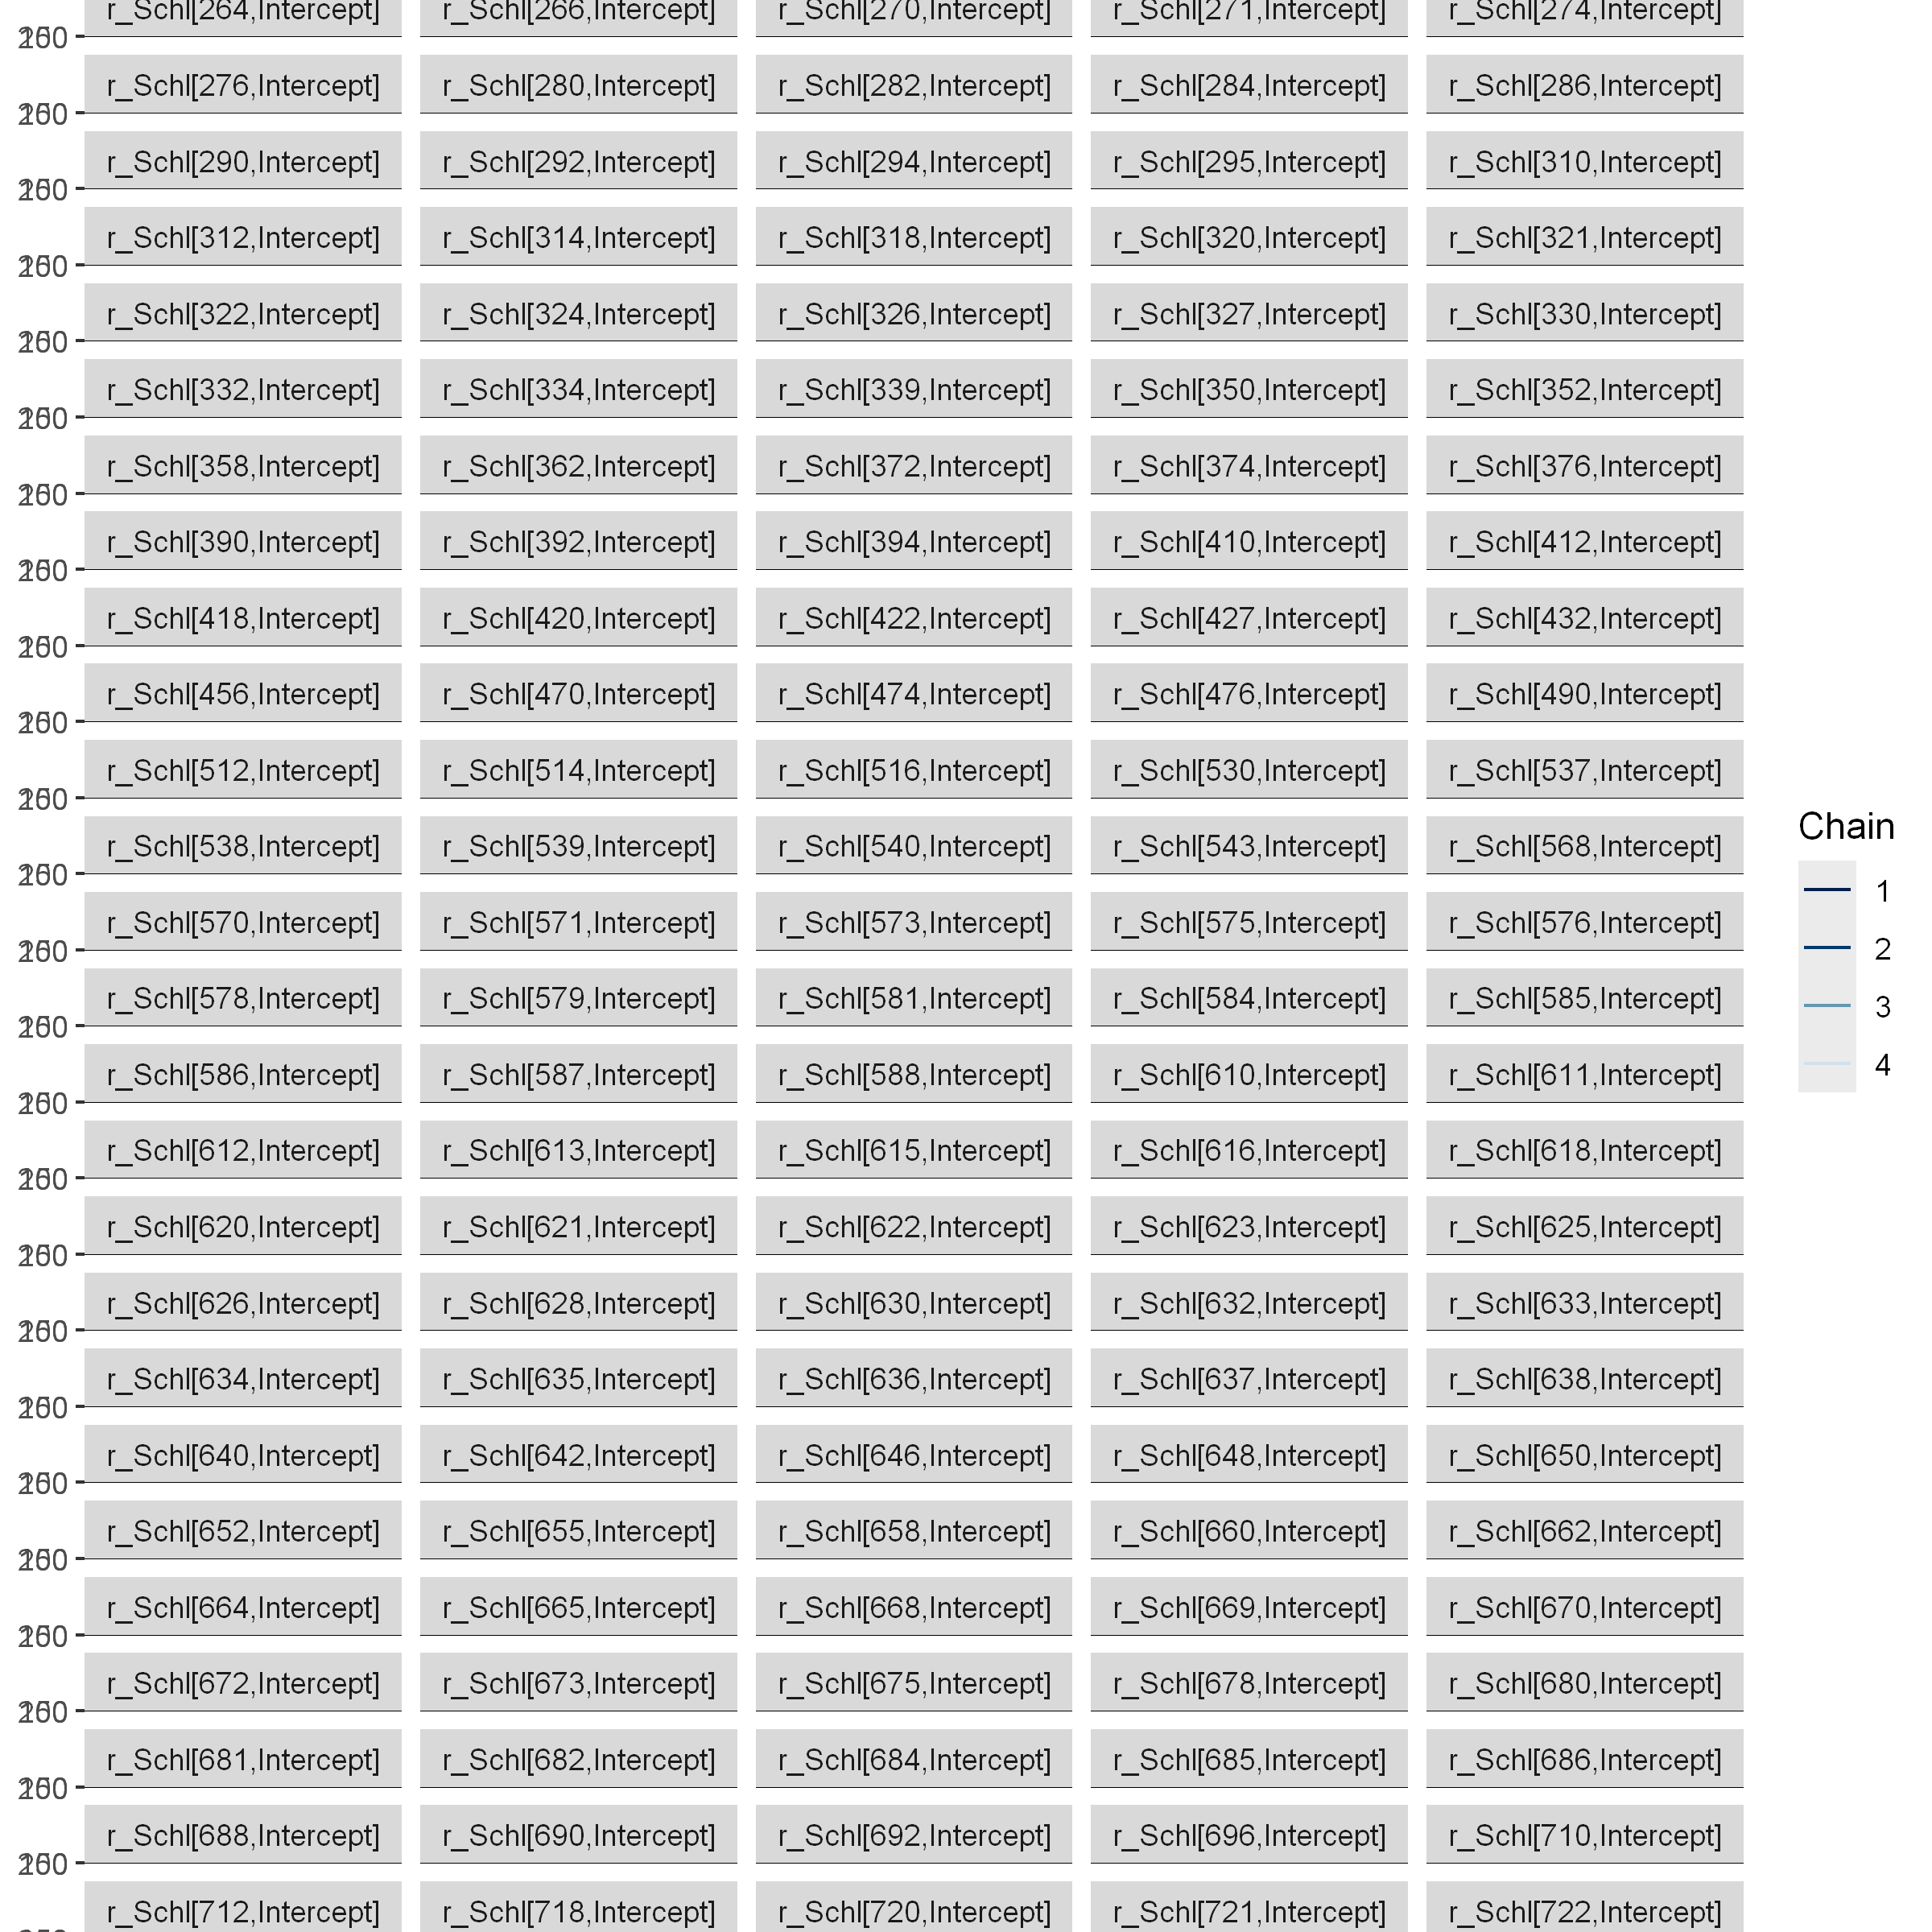

In [3]:
library(bayesplot)
library(ggplot2) # This is the missing piece

# Generate the plot for your 30 categories
mcmc_rank_overlay(brms_regses_final_production, 
                  regex_pars = "^r_") + 
  facet_wrap(~ parameter, ncol = 5)

Warning message:
"package 'posterior' was built under R version 4.4.3"
This is posterior version 1.6.1


Attaching package: 'posterior'


The following object is masked from 'package:bayesplot':

    rhat


The following objects are masked from 'package:stats':

    mad, sd, var


The following objects are masked from 'package:base':

    %in%, match




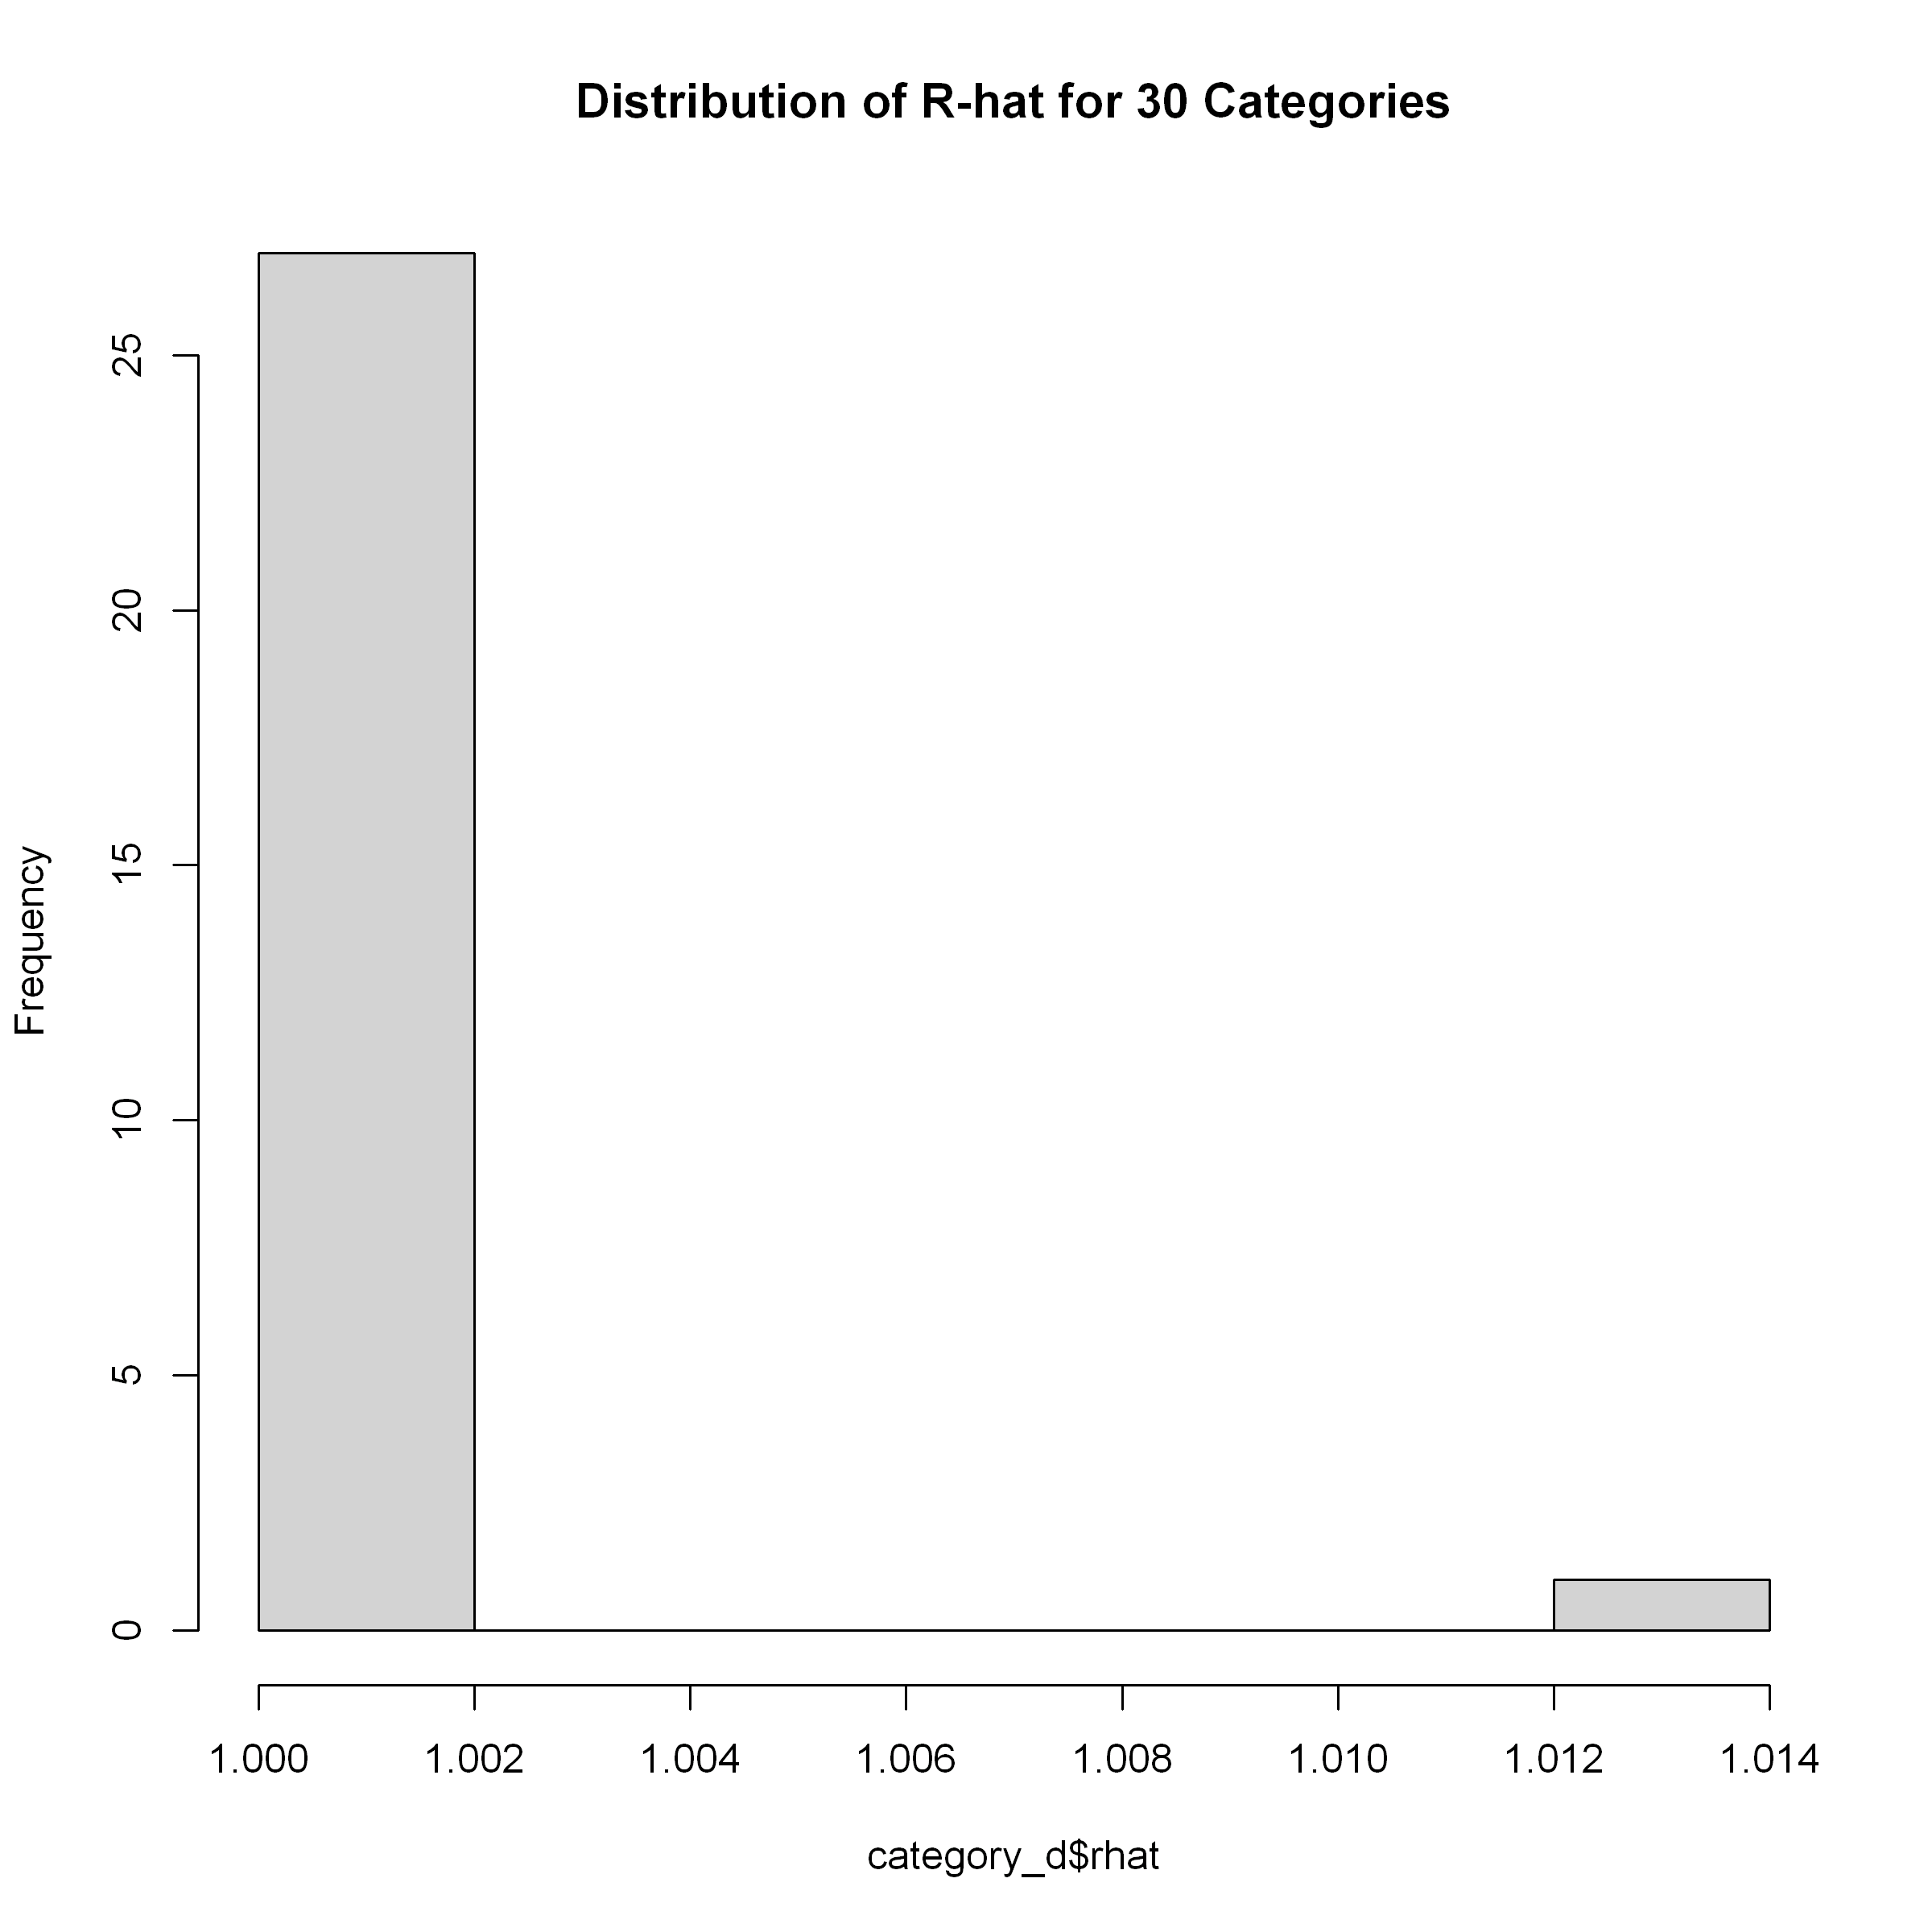

In [4]:
library(posterior)
d <- summarize_draws(brms_regses_final_production)
# Filter for your 30 category parameters
category_d <- d[grep("^b_", d$variable), ]
hist(category_d$rhat, main="Distribution of R-hat for 30 Categories")

## Trace Plots

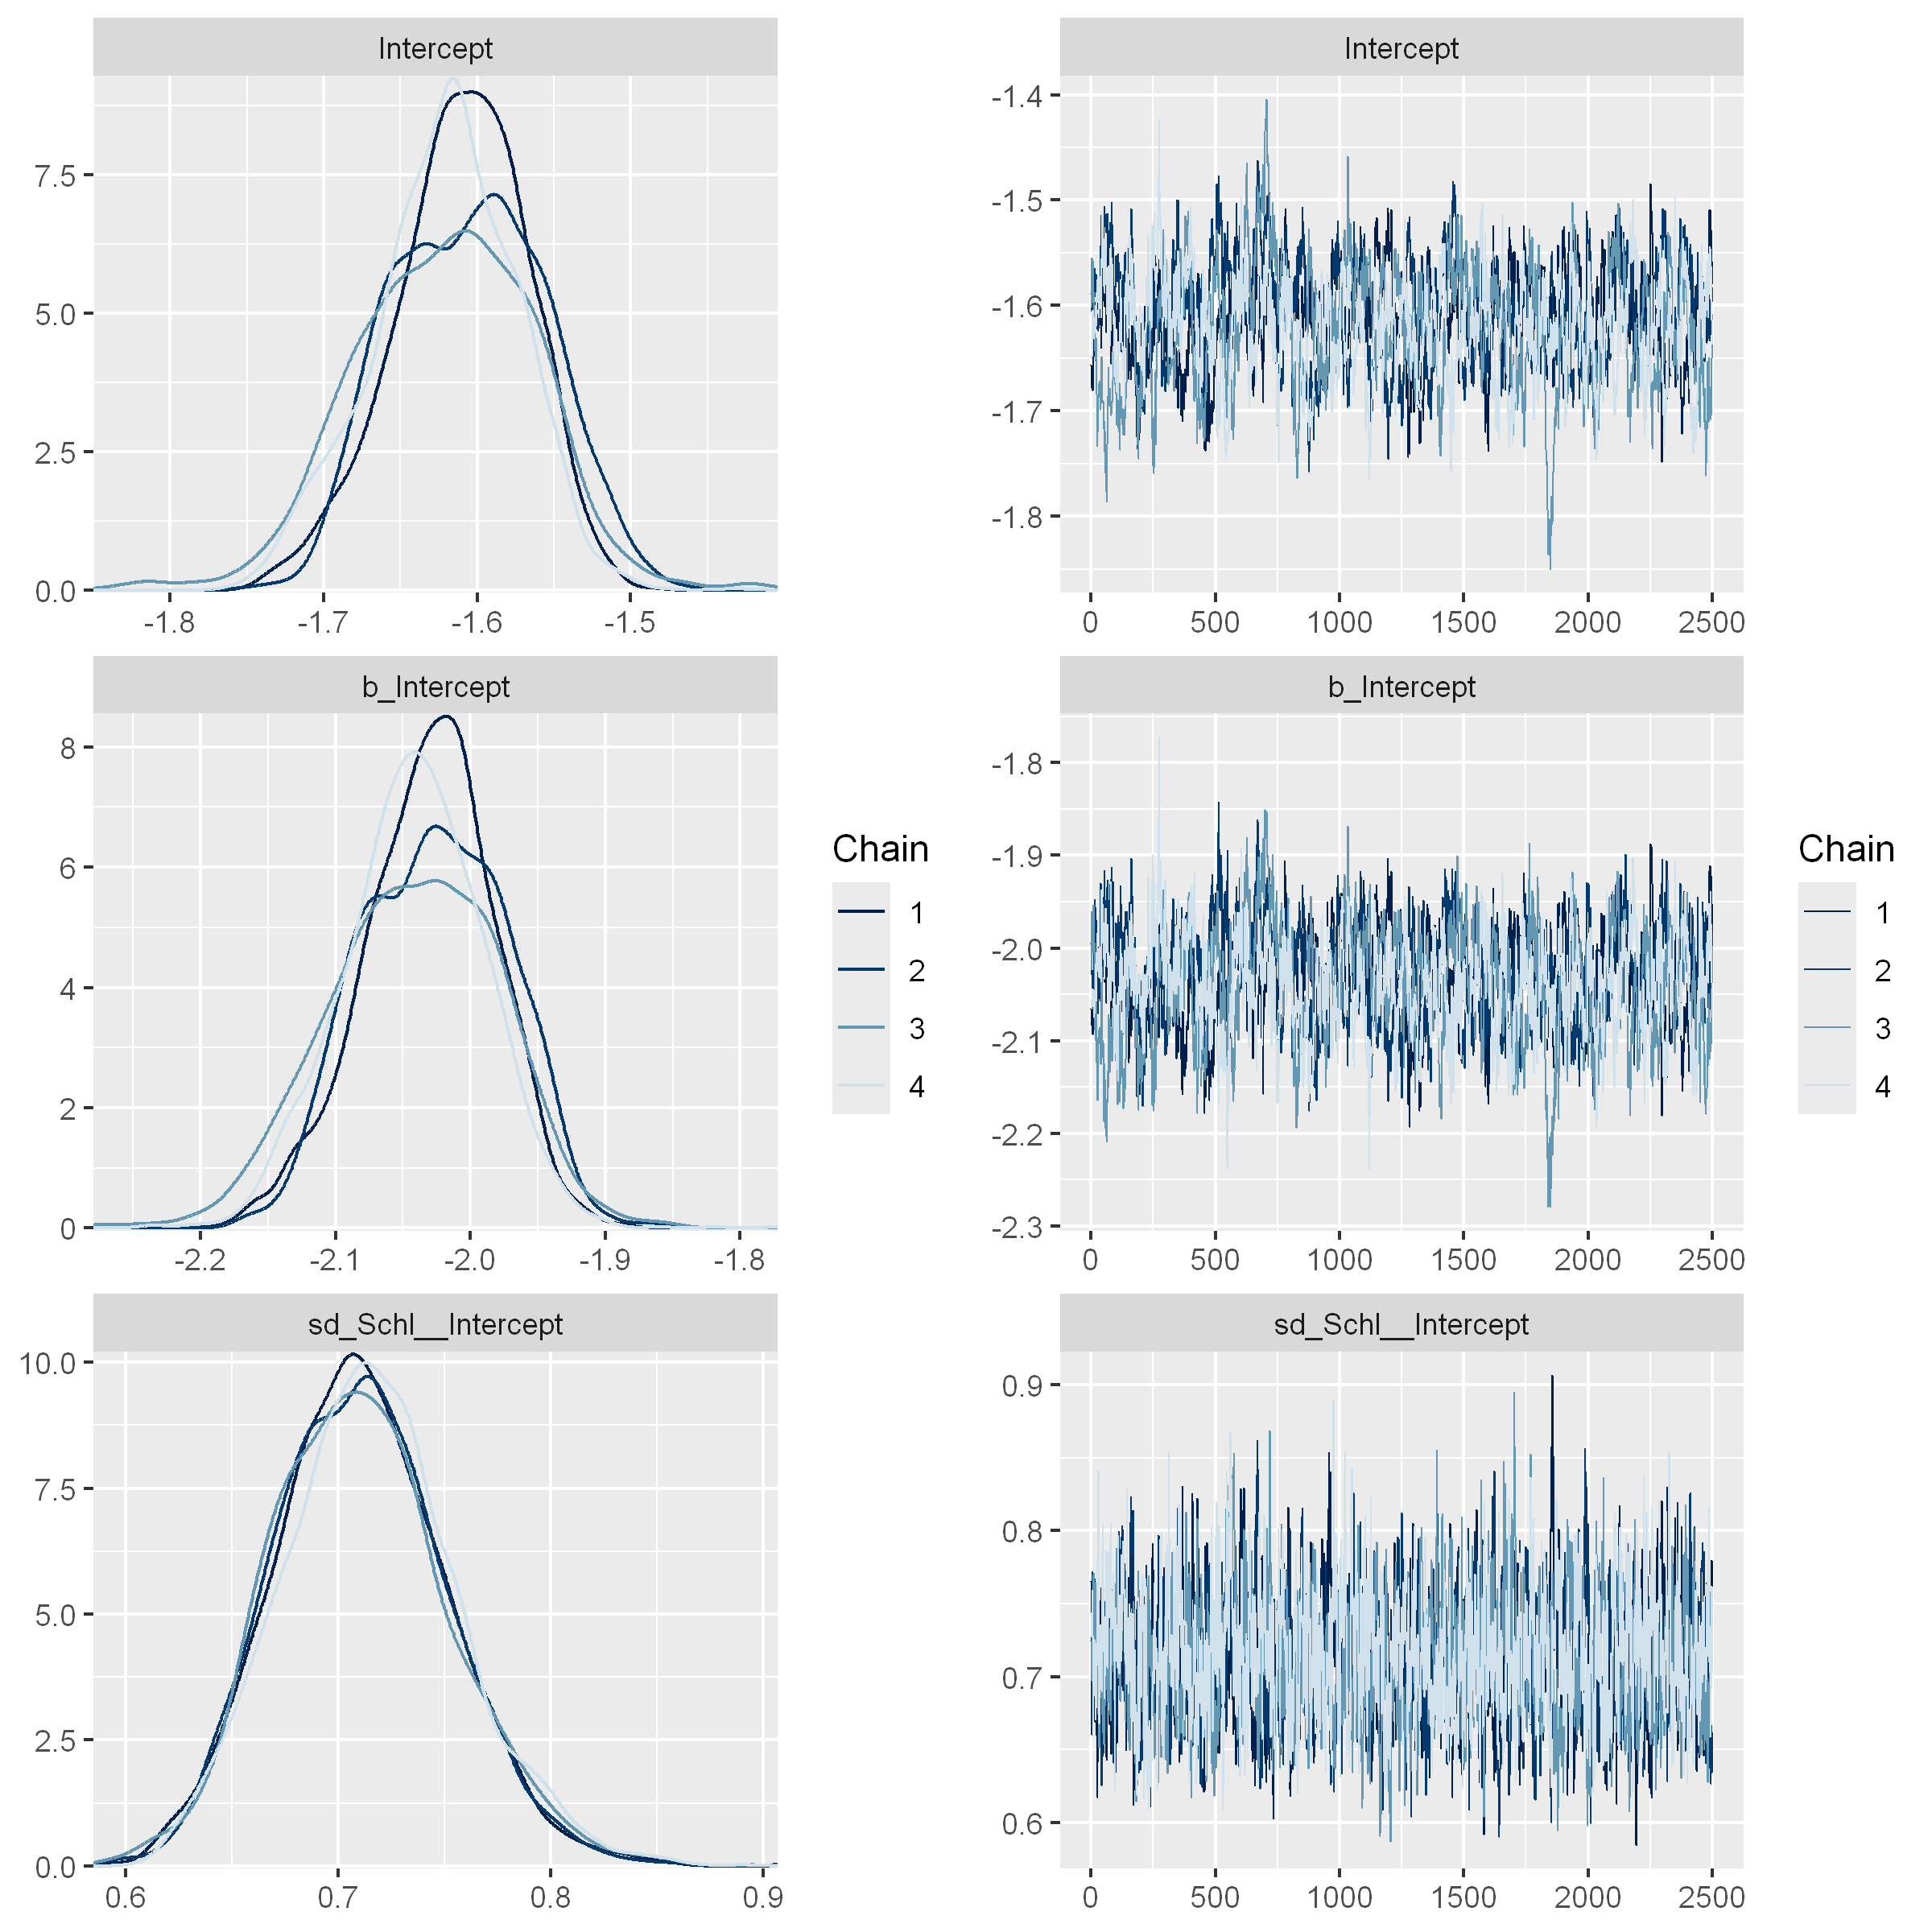

In [5]:
library(bayesplot)
library(ggplot2)

# Select your main parameters (Global Intercept and Variances)
# 'sd_Group__Intercept' is the typical brms name for random intercept SD
params <- c("Intercept","b_Intercept", "sd_Schl__Intercept")

# Generate the side-by-side plot
mcmc_combo(brms_regses_final_production, 
                pars = params,
                combo = c("dens_overlay", "trace"))

## Forest Plot

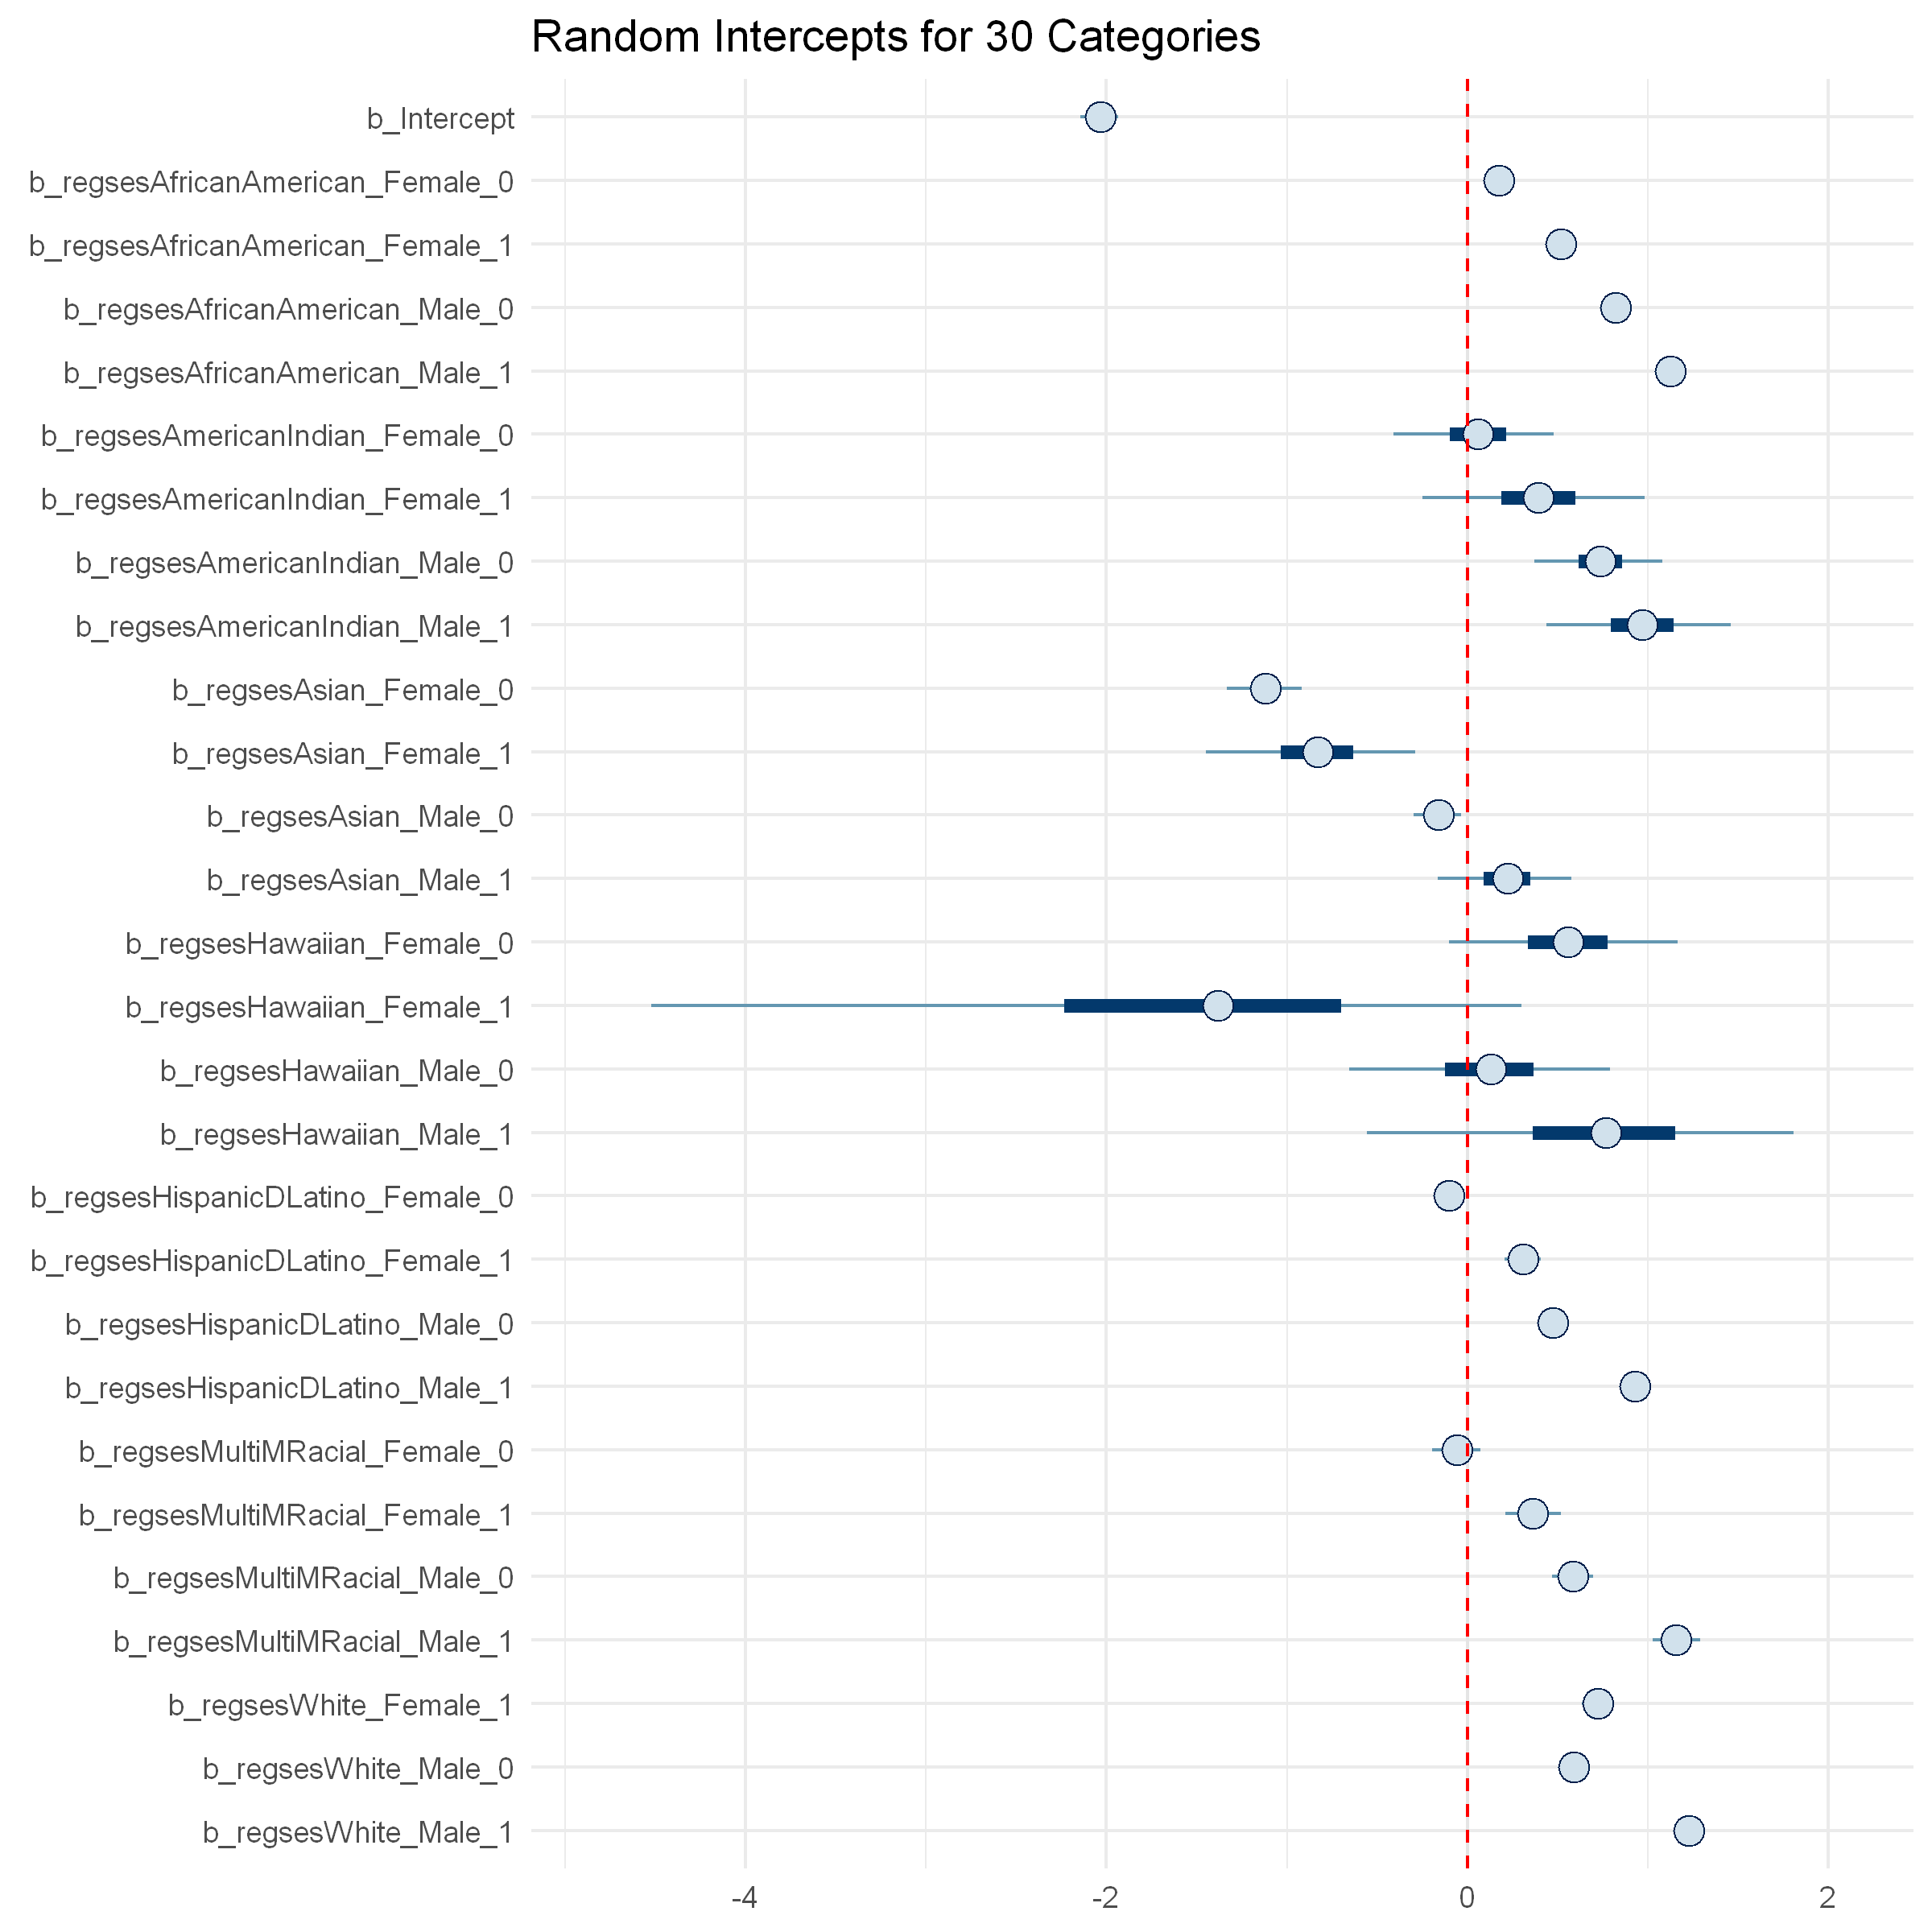

In [6]:
library(bayesplot)
library(ggplot2)

# Create the forest plot
# Using regex "^r_" grabs all 30 random intercepts automatically
p_forest <- mcmc_intervals(brms_regses_final_production, 
                           regex_pars = "^b_",
                           prob = 0.5,      # Thick inner line
                           prob_outer = 0.95) + # Thin outer line
            vline_0(color = "red", linetype = "dashed") + # Reference line at zero
            ggtitle("Random Intercepts for 30 Categories") +
            theme_minimal()

# Display the plot
print(p_forest)

In [ ]:
library(bayesplot)
pp_check(brms_regses_final_production, nsamples = 50)

In [ ]:
# Generate simulations
y_rep <- posterior_predict(brms_regses_final_production)
y_obs <- brms_regses_final_production$is_sped[[1]] # Replace with your DV name

# Calculate a simple PPP based on the mean
ppp_mean <- mean(rowMeans(y_rep) > mean(y_obs))
print(ppp_mean)